In [1]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import math
import json
import cv2
import os

import polyscope as ps
ps.init()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.6 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.3


# Ray Tracing for Ground Truth
This section aims to obtain ground thruth data from an animated scene simulated in blender
As a demonstration this script only looks at one frame of the sim however the functions and procedures for the full script are the same.

Loading Mesh and Camera Data

In [24]:
def read_cam_data(path="../blender_camera_data.json"):
    cams = []
    with open(path) as f:
        cam_data = json.load(f)

    # Blender to O3D Coordinate Conversion Matrix - rotating -90 about x
    rot_mat = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0],
    [0, -1, 0, 0],
    [0, 0, 0, 1]], dtype=np.float32)

    # 180 around y - because there was trouble with the cameras facing the wrong way and I'm still not entirely sure why
    rot_y_mat = np.array([
        [-1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, -1, 0],
        [0, 0, 0, 1]
    ], dtype=np.float32)

    for i in range(4):
        cam_info = cam_data[i]
        
        #Get Matricies
        # Extrinsics
        ex_mat = np.linalg.inv(np.array(cam_info["extrinsic_mat"], dtype=np.float32))

        ex_cam_rot = rot_mat @ ex_mat # converting to o3d
        ex_cam_rot_y = ex_cam_rot @ rot_y_mat
        ex_world_rotated = np.linalg.inv(ex_cam_rot_y) #camera to world matrix - because thats what create_rays_pinhole_needs

        # Intrinsics
        in_mat = np.array(cam_info["intrinsics"]["intrinsic_matrix"], dtype=np.float32)

        cam_tmp = {
            'ex_tensor' : o3d.core.Tensor(ex_world_rotated),
            'in_tensor' : o3d.core.Tensor(in_mat),
            'w' : cam_info["intrinsics"]["width"],
            'h' : cam_info["intrinsics"]["height"]
        }
        cams.append(cam_tmp)
    return cams

def load_mesh(path=os.path.abspath("/home/humense/arhma-capstone/simulation/meshes_temp/frame_0001.ply")): # Temporary path
   
   mesh = o3d.io.read_triangle_mesh(path)
#    # Blender to O3D Coordinate Conversion Matrix - rotating -90 about x
#    rot_mat = np.array([
#        [1, 0, 0],
#        [0, 0, 1],
#        [0, -1, 0]], dtype=np.float32)

#    mesh_verts = np.asarray(mesh.vertices)
#    mesh_verts = (rot_mat @ mesh_verts.T).T
#    mesh.vertices = o3d.utility.Vector3dVector(mesh_verts)
   
   return mesh

cams_data = read_cam_data()
o3dmesh = load_mesh()
ps.remove_all_structures()

Set Up Polyscope Scene

In [13]:
def polyscope_cam_params(camera_data):
    ex_world = np.linalg.inv(camera_data['ex_tensor'].numpy())
    in_mat = camera_data['in_tensor'].numpy()
    w = camera_data['w']
    h = camera_data['h']

    # Intrinsics
    fy = in_mat[1, 1]
    fov_vertical_rad = 2 * math.atan(h / (2 * fy))
    fov_vertical_deg = math.degrees(fov_vertical_rad)
    aspect_ratio = w / h
    intrinsics = ps.CameraIntrinsics(fov_vertical_deg=fov_vertical_deg, aspect=aspect_ratio)

    # Extrinsics
    cam_pos = ex_world[:3, 3].tolist() # numpy array dosn't work for cam extrinsics in polyscope
    look_dir = (ex_world[:3, 2] / np.linalg.norm(ex_world[:3, 2])).tolist()
    up_dir = (ex_world[:3, 1] / np.linalg.norm(ex_world[:3, 1])).tolist()
    extrinsics = ps.CameraExtrinsics(root=cam_pos, look_dir=look_dir, up_dir=up_dir)

    print(f"cam_pos: {cam_pos}")
    print(f"look_dir: {look_dir}")
    print(f"up_dir: {up_dir}")

    return ps.CameraParameters(intrinsics, extrinsics)

for i, cam in enumerate(cams_data):
    print(f"Camera_{i+1} --------------------------")
    params = polyscope_cam_params(cam)
    cam = ps.register_camera_view(f"Camera {i+1}", params)

faces = np.asarray(o3dmesh.triangles)
vertices = np.asarray(o3dmesh.vertices)
ps_mesh = ps.register_surface_mesh("mesh", vertices, faces)

ps.show()
ps_mesh.remove() # remove mesh but keep the cameras in the scene

Camera_1 --------------------------
cam_pos: [5.0, 2.0, 2.066411074913045e-14]
look_dir: [-0.9805806875228882, -0.19611620903015137, -6.124738405333119e-08]
up_dir: [-0.19611620903015137, 0.9805806875228882, -7.872832696875776e-08]
Camera_2 --------------------------
cam_pos: [-5.0, 2.0, 2.066411074913045e-14]
look_dir: [0.9805806875228882, -0.19611620903015137, -6.124738405333119e-08]
up_dir: [0.19611620903015137, 0.9805806875228882, -7.872832696875776e-08]
Camera_3 --------------------------
cam_pos: [1.2223381689962197e-14, 2.0, -5.0]
look_dir: [1.025371574314704e-07, -0.19611608982086182, 0.9805806875228882]
up_dir: [-6.691534792935272e-08, 0.9805806875228882, 0.19611608982086182]
Camera_4 --------------------------
cam_pos: [-0.0, 2.0, 5.0]
look_dir: [-0.0, -0.19611608982086182, -0.9805806875228882]
up_dir: [-0.0, 0.9805806875228882, -0.19611608982086182]


Setting Up Scene for Ray Tracing with Open3D

ray casting complete!


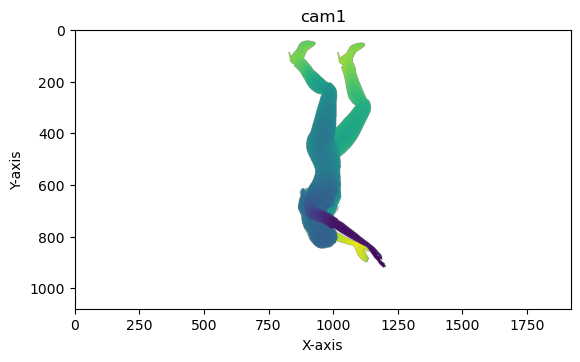

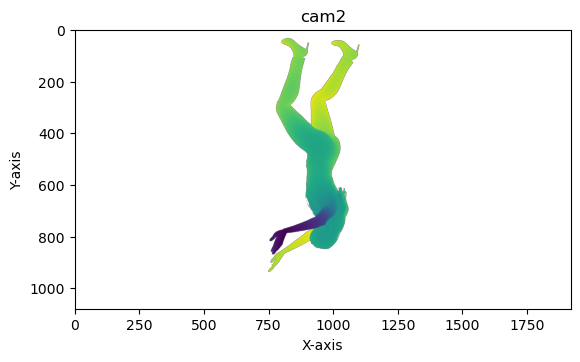

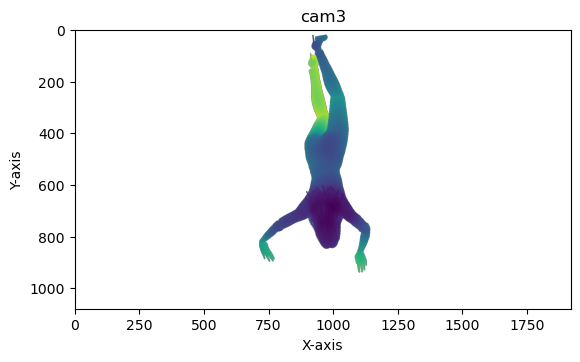

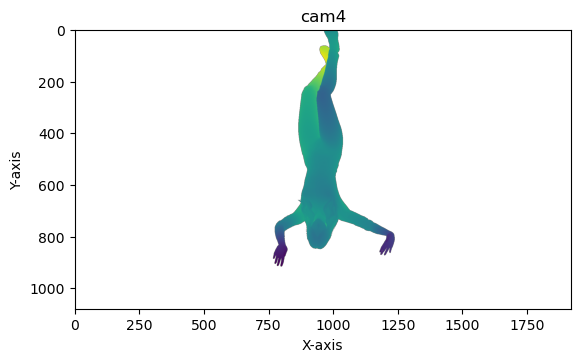

In [4]:
def ray_cast(scene, cams):

    ans = []
    
    for cam in cams:
        rays = o3d.t.geometry.RaycastingScene.create_rays_pinhole(
            intrinsic_matrix=cam['in_tensor'],
            extrinsic_matrix=cam['ex_tensor'],
            width_px=cam["w"],
            height_px=cam["h"]
        )
        
        cast_ans = scene.cast_rays(rays)
        ans.append(cast_ans)
    
    return ans

scene = o3d.t.geometry.RaycastingScene()
scene.add_triangles(o3d.t.geometry.TriangleMesh.from_legacy(o3dmesh))
cast_ans = ray_cast(scene, cams_data)
print("ray casting complete!")

for i, a in enumerate(cast_ans):
            # Display Result - for debugging ------------------
            plt.imshow(a['t_hit'].numpy())
            plt.title(f"cam{i+1}")
            plt.xlabel("X-axis")
            plt.ylabel("Y-axis")
            plt.show()


Saving the Ground Truth - Do NOT run unless happy with the ray_tracing result

In [6]:
def build_dict(ans, mesh):
    # should be based off the camera data but since its known its fine for now
    width_px = 1920
    height_px = 1080

    # Get triangle and vertex data from the passed object_mesh (which is already transformed)
    faces = np.asarray(mesh.triangles)
    vertices = np.asarray(mesh.vertices)
    triangle_vertices = vertices[faces]

    primitive_ids = ans['primitive_ids'].numpy().reshape((height_px, width_px))
    primitive_uvs = ans['primitive_uvs'].numpy().reshape((height_px, width_px , 2))

    camera_hit_list = []
    count = 0
    for y in range(height_px):
        for x in range(width_px):
            tri_id = primitive_ids[y,x]

            if tri_id == o3d.t.geometry.RaycastingScene.INVALID_ID:
                count += 1
                continue  # Skip rays that didn't hit anything

            u, v = primitive_uvs[y, x]
            v0, v1, v2 = triangle_vertices[tri_id]
            hit_point = (1 - u - v) * v0 + u * v1 + v * v2

            dv1 = float(np.linalg.norm(hit_point - v0))
            dv2 = float(np.linalg.norm(hit_point - v1))
            dv3 = float(np.linalg.norm(hit_point - v2))

            # add data to list
            camera_hit_list.append({
                "pixel": [x, y],
                "triangle_id": int(tri_id),
                "hit": hit_point.tolist(),
                "dv1": dv1,
                "dv2": dv2,
                "dv3": dv3
            })

    return camera_hit_list

mesh_folder = os.path.abspath("ground_truth_data")
for i, a in enumerate(cast_ans):
    data = build_dict(a, o3dmesh)
    cam_path = os.path.join(mesh_folder, f"Camera_{i+1}")
    os.makedirs(cam_path, exist_ok=True)
    
    file_path = os.path.join(cam_path, "frame_0001.json")
    with open(file_path, "w") as f: 
        json.dump(data, f, indent=2)

    print(f"Ground Truth for Camera_{i+1} added")

Ground Truth for Camera_1 added
Ground Truth for Camera_2 added
Ground Truth for Camera_3 added
Ground Truth for Camera_4 added


Read and Plot from .json

In [10]:
def get_point_clouds(cams):
    all_points = []
    all_directions = []

    for i in range(4):
        with open(f'ground_truth_data/Camera_{i+1}/frame_0001.json', 'r') as f:    
            camera_hit_list = json.load(f)

        # Extract just the hit points
        hit_points = np.array([entry['hit'] for entry in camera_hit_list if entry['hit'] is not None], dtype=np.float32)

        cam_origin = np.linalg.inv(cams[i]['ex_tensor'].numpy())[:3,3]
        direction = hit_points - cam_origin

        # Convert to Point Cloud
        # pcd = o3d.geometry.PointCloud()
        # pcd.points = o3d.utility.Vector3dVector(hit_points)

        all_points.append(hit_points)
        all_directions.append(direction)
        print("pt cld added")

    return all_points, all_directions 

hit_pts, directions = get_point_clouds(cams_data)
pcds = []
for i in range(len(hit_pts)):
    pcd = ps.register_point_cloud(f"Ground Truth Cam{i+1}", hit_pts[i])
    #pcd.add_vector_quantity(f"Cam{i+1} vectors", directions[i], enabled=True)
    pcds.append(pcd)

ps.show()

for pcd in pcds: # remove the meshes but keep the cameras
   pcd.remove()

pt cld added
pt cld added
pt cld added
pt cld added


# Depth Renders to Point Cloud
This section aims to convert depth images rendered from the blender simulation into a point cloud with normals.

In [27]:
def refine_normals(pcd, extrinsic_vec):
    
    points = np.asarray(pcd.points)
    normals = np.asarray(pcd.normals)
    R = extrinsic_vec[:3, :3]
    t = extrinsic_vec[:3, 3]
    cam_center = -R.T @ t

    negative_count = 0

    print(f'points: {points.shape}')
    print(f'normals: {normals.shape}')
    print(f'camera center {cam_center}')

    # compute dot product of camera center towards the point and the normal vector.
    for i, point in enumerate(points):
        normal_vec = normals[i]
        view_vector = point - cam_center
        view_vector /= np.linalg.norm(view_vector)

        product = view_vector @ normal_vec

        # if the dot product is negative then flip the normal
        if product < 0: 
            negative_count += 1
            normals[i] = -normal_vec
    
    print(negative_count)
    pcd.normals = o3d.utility.Vector3dVector(normals)
    
    return pcd

def load_normalized_depth(path, min_depth, max_depth):

    depth = cv2.imread(path, cv2.IMREAD_UNCHANGED).astype(np.float32)
    
    # the way open3d loaded the images has them upside down
    depth = cv2.flip(depth, 0)
    depth = cv2.flip(depth, 1)
    
    depth = depth[:, :, 0]

    # Normalize [0, 255] -> [0, 1]
    depth_norm = depth / 255.0
    depth = depth_norm * (max_depth - min_depth) + min_depth # Map back to metric depth [min_depth, max_depth]

    #depth[depth == min_depth] = 0.0 # masking out 
 
    return o3d.geometry.Image(depth)

def img_to_pcd(cams, dir='../renders_scaled', min_depth=3.8, max_depth=6.8):
    
    pcds = []
    for i, cam in enumerate(cams):
        #extrinsics = np.linalg.inv(cam['ex_tensor'].numpy()) # using cam local
        extrinsics = cam['ex_tensor'].numpy() # using global system
        extrinsics = extrinsics.astype(np.float64)

        cam_pos = extrinsics[:3, 3].tolist()
        print(f"cam_{i+1}: {cam_pos}")

        intrinsics = cam['in_tensor'].numpy()
        intrinsics = intrinsics.astype(np.float64)

        cam_intrinsics = o3d.camera.PinholeCameraIntrinsic(
            cam['w'], cam['h'], intrinsics
        )

        depth_img_path = os.path.join(dir, f"Camera_{i+1}/depth_png/depth_norm_0001.png")
        rgb_img_path = os.path.join(dir, f"Camera_{i+1}/rgb/rgb_0001.png")
            
        depth_img =load_normalized_depth(depth_img_path, min_depth, max_depth) # using opencv
        rgb_img = o3d.io.read_image(rgb_img_path)
        
        rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(rgb_img, depth_img, 1.0, max_depth, False) 
        pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, cam_intrinsics, extrinsics)

        pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))
        pcd.orient_normals_towards_camera_location(extrinsics[:3, 3].tolist()) # orient based on the camera position?

        refine_normals(pcd, extrinsics)

        pcds.append(pcd) 
    return pcds

img_pcds = img_to_pcd(cams_data)

depth_pcds = []
for i, pcd in enumerate(img_pcds):
    downsampled = pcd.voxel_down_sample(voxel_size=0.01)
    points = np.asarray(downsampled.points) #downsampled.points)
    normals = np.asarray(downsampled.normals)
    if points.size > 0:
        depth_pcd = ps.register_point_cloud(f"Camera {i+1} points", points)
        depth_pcd.add_vector_quantity("normal vectors", normals)
        depth_pcds.append(depth_pcd)

ps.show()
ps.remove_all_structures() # clear the whole scene



cam_1: [2.471137463544437e-07, -0.9805802702903748, 5.295135498046875]
points: (115696, 3)
normals: (115696, 3)
camera center [4.99999962e+00 1.99999984e+00 2.88499422e-18]
6138
cam_2: [-2.471137463544437e-07, -0.9805802702903748, 5.295135498046875]
points: (113112, 3)
normals: (113112, 3)
camera center [-4.99999962e+00  1.99999984e+00  2.88499422e-18]
5709
cam_3: [-6.085640507080825e-07, -0.9805809259414673, 5.295135498046875]
points: (113532, 3)
normals: (113532, 3)
camera center [-5.30837750e-15  1.99999999e+00 -4.99999991e+00]
392
cam_4: [-0.0, -0.9805809259414673, 5.295135498046875]
points: (118308, 3)
normals: (118308, 3)
camera center [0.         1.99999999 4.99999991]
116127
